In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
NCAAW_2026 = pd.read_csv('sports_ref_NCAAW_2026.csv')

"The current state of the voter corresponds to the team that the voter now believes
to be the best. At each time step, the voter reevaluates his judgement in the following
way: given that he currently believes team i to be the best, he picks (at random) a game played by team i against some opponent j. With probability p, the voter moves to the
state corresponding to the game’s winner; with probability (1 – p), the voter moves to the
losing team’s state." pg 2-3

"Suppose team i has played a total of N_i games, with the kth game (k ≤ N_i) being
played against opponent o_k. Let I_ik be an indicator equal to 1 if team i won its kth game,
and 0 if team i lost its kth game. Then the transition probabilities t_ij from state i in the
Markov chain are defined as
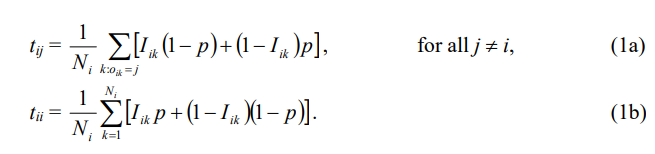" pg 3

In [ ]:
t[i][j] = (1/N[i])*sum()

In [ ]:
# AI:G
# Extract valid team records from the scraped table
teams = NCAAW_2026.iloc[:, 1].astype(str)
wins = pd.to_numeric(NCAAW_2026.iloc[:, 3], errors="coerce")
losses = pd.to_numeric(NCAAW_2026.iloc[:, 4], errors="coerce")

valid = teams.notna() & wins.notna() & losses.notna()
teams = teams[valid].to_numpy()
wins = wins[valid].to_numpy(dtype=float)
losses = losses[valid].to_numpy(dtype=float)

# Remove duplicate team names, if present
unique_teams, indices = np.unique(teams, return_index=True)
teams = unique_teams
wins = wins[indices]
losses = losses[indices]

n = len(teams)
win_rates = wins / (wins + losses)

# p: probability of moving to the game's winner
p = 0.75

# Transition matrix: rows are current teams, columns are next teams
T = np.zeros((n, n))

for i in range(n):
    opponents = [j for j in range(n) if j != i]

    for j in opponents:
        # Estimated probability that team i beats team j
        q_ij = win_rates[i] / (win_rates[i] + win_rates[j])

        # Team i wins: remain with probability p, move to opponent with 1-p
        # Team i loses: move to opponent with probability p, remain with 1-p
        stay_probability = q_ij * p + (1 - q_ij) * (1 - p)
        move_probability = q_ij * (1 - p) + (1 - q_ij) * p

        T[i, i] += stay_probability / len(opponents)
        T[i, j] += move_probability / len(opponents)

# Verify that each row is a probability distribution
T /= T.sum(axis=1, keepdims=True)

# Estimate the stationary distribution
stationary = np.ones(n) / n

for _ in range(10000):
    new_stationary = stationary @ T
    if np.max(np.abs(new_stationary - stationary)) < 1e-12:
        break
    stationary = new_stationary

rankings = pd.DataFrame({
    "Team": teams,
    "Stationary Probability": stationary,
    "Win Rate": win_rates
}).sort_values("Stationary Probability", ascending=False)

rankings.head(25)

,Team,Stationary Probability,Win Rate
59,Connecticut NCAA,0.003819,0.974359
323,UCLA NCAA,0.003818,0.973684
275,South Carolina NCAA,0.003685,0.900000
309,Texas NCAA,0.003681,0.897436
190,Murray State NCAA,0.003659,0.885714
241,Princeton NCAA,0.003623,0.866667
84,FDU NCAA,0.003604,0.857143
336,Vanderbilt NCAA,0.003596,0.852941
210,North Dakota State,0.003596,0.852941
85,Fairfield NCAA,0.003588,0.848485
